# Dataset Exploration

Minimal EDA for the three benchmark datasets used in this project:

- **Communities & Crime** (UCI) — regression on `ViolentCrimesPerPop`
- **NHANES 2013-2014** (CDC) — classification on diabetes diagnosis (`DIQ010`)
- **Lending Club** — classification on loan default

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data import load_communities, load_lending_club, load_nhanes

## 1. NHANES 2013-2014

In [ ]:
X_nh, y_nh = load_nhanes()  # after dataset-level cleaning
print('X:', X_nh.shape, '   y:', y_nh.shape)
print('diabetes prevalence:', round(float(y_nh.mean()), 3))
print('\nclass balance:')
print(y_nh.value_counts().rename({0: 'no diabetes', 1: 'diabetes'}))

X: (9236, 112)    y: (9236,)
diabetes prevalence: 0.078

class balance:
DIQ010
no diabetes    8514
diabetes        722
Name: count, dtype: int64


In [3]:
X_nh.describe().round(3)

,RIDSTATR,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDCITZN,SIALANG,SIAPROXY,...,OHX23TC,OHX24TC,OHX25TC,OHX26TC,OHX27TC,OHX28TC,OHX29TC,OHX30TC,OHX31TC,OHX32TC
count,9236.0,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,...,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000,9236.000
mean,2.0,1.508,32.509,3.093,3.289,1.507,1.196,1.098,1.107,1.655,...,2.001,2.020,2.022,2.006,1.952,2.037,2.092,2.645,2.852,3.681
std,0.0,0.500,23.913,1.263,1.609,0.500,0.397,0.297,0.309,0.475,...,0.652,0.632,0.638,0.660,0.706,0.835,0.899,0.955,1.004,0.745
min,2.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,2.000,2.000
25%,2.0,1.000,11.000,2.000,2.000,1.000,1.000,1.000,1.000,1.000,...,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,4.000
50%,2.0,2.000,28.000,3.000,3.000,2.000,1.000,1.000,1.000,2.000,...,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,2.000,4.000
75%,2.0,2.000,52.000,4.000,4.000,2.000,1.000,1.000,1.000,2.000,...,2.000,2.000,2.000,2.000,2.000,2.000,2.000,4.000,4.000,4.000
max,2.0,2.000,80.000,5.000,7.000,2.000,2.000,2.000,2.000,2.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000,5.000


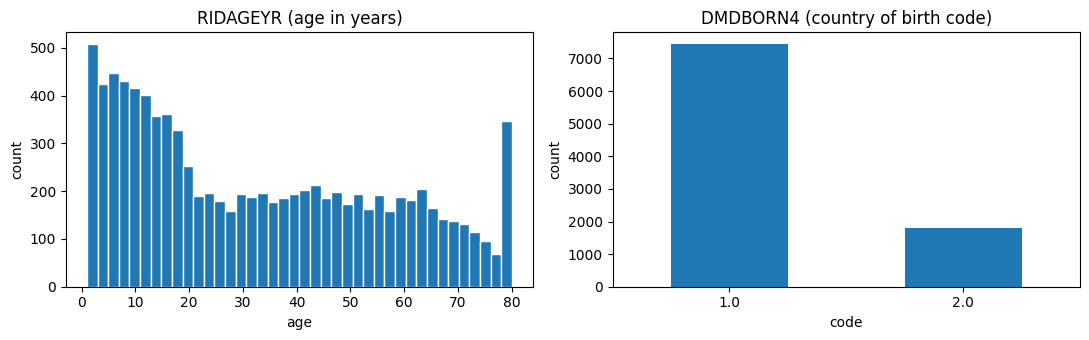

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

X_nh['RIDAGEYR'].plot.hist(bins=40, ax=axes[0], edgecolor='white')
axes[0].set(title='RIDAGEYR (age in years)', xlabel='age', ylabel='count')

X_nh['DMDBORN4'].value_counts().sort_index().plot.bar(ax=axes[1], rot=0)
axes[1].set(title='DMDBORN4 (country of birth code)', xlabel='code', ylabel='count')

fig.tight_layout()

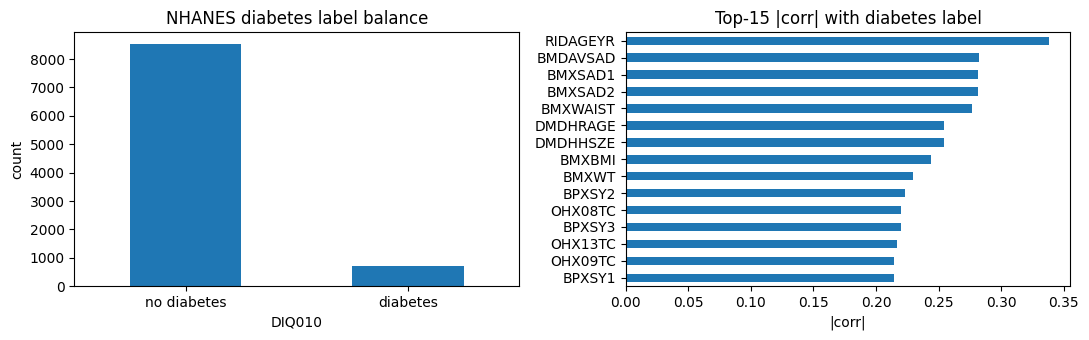

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
y_nh.value_counts().rename({0: 'no diabetes', 1: 'diabetes'}).plot.bar(ax=axes[0], rot=0)
axes[0].set(title='NHANES diabetes label balance', ylabel='count')

X_nh_varying = X_nh.loc[:, X_nh.std(numeric_only=True) > 0]
top_nh = X_nh_varying.corrwith(y_nh).abs().dropna().sort_values(ascending=False).head(15)
top_nh.iloc[::-1].plot.barh(ax=axes[1])
axes[1].set(title='Top-15 |corr| with diabetes label', xlabel='|corr|')
plt.tight_layout()
plt.show()

TODO: EDA below two datasets and construct the preprocessing pipeline

## 2. Communities & Crime

In [6]:
X_cc, y_cc = load_communities()
print('X:', X_cc.shape, '   y:', y_cc.shape)
print('missing (after preprocessing):', int(X_cc.isna().sum().sum()))
print('\ntarget (ViolentCrimesPerPop) summary:')
print(y_cc.describe().round(3))
X_cc.head()

X: (1994, 100)    y: (1994,)
missing (after preprocessing): 0

target (ViolentCrimesPerPop) summary:
count    1994.000
mean        0.238
std         0.233
min         0.000
25%         0.070
50%         0.150
75%         0.330
max         1.000
Name: ViolentCrimesPerPop, dtype: float64


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.0,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.0,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.0,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.0,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.0,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00


In [7]:
X_cc.describe().round(3)

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
count,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,...,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000,1994.000
mean,0.058,0.463,0.180,0.754,0.154,0.144,0.424,0.494,0.336,0.423,...,0.023,0.216,0.609,0.535,0.626,0.652,0.065,0.233,0.162,0.094
std,0.127,0.164,0.253,0.244,0.209,0.232,0.155,0.144,0.167,0.179,...,0.100,0.231,0.204,0.181,0.201,0.198,0.109,0.203,0.229,0.240
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.010,0.350,0.020,0.630,0.040,0.010,0.340,0.410,0.250,0.300,...,0.000,0.060,0.470,0.420,0.520,0.560,0.020,0.100,0.020,0.000
50%,0.020,0.440,0.060,0.850,0.070,0.040,0.400,0.480,0.290,0.420,...,0.000,0.130,0.630,0.540,0.670,0.700,0.040,0.170,0.070,0.000
75%,0.050,0.540,0.230,0.940,0.170,0.160,0.470,0.540,0.360,0.530,...,0.000,0.280,0.778,0.660,0.770,0.790,0.070,0.280,0.190,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


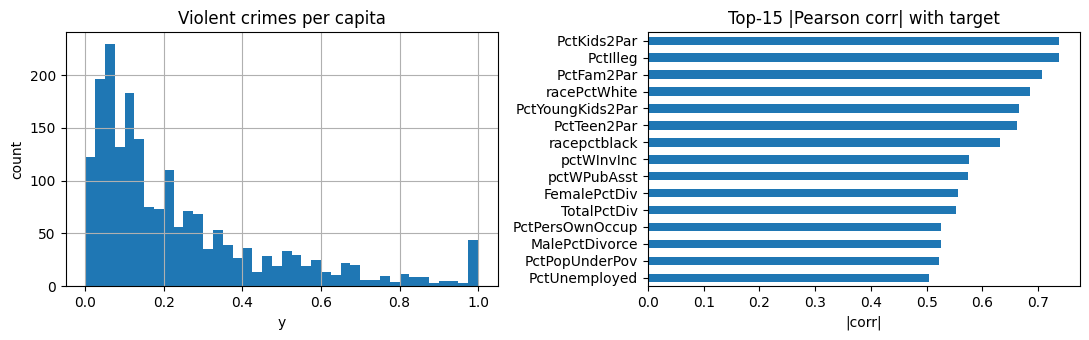

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
y_cc.hist(bins=40, ax=axes[0])
axes[0].set(title='Violent crimes per capita', xlabel='y', ylabel='count')

top_corr = X_cc.corrwith(y_cc).abs().sort_values(ascending=False).head(15)
top_corr.iloc[::-1].plot.barh(ax=axes[1])
axes[1].set(title='Top-15 |Pearson corr| with target', xlabel='|corr|')
plt.tight_layout()
plt.show()

## 3. Lending Club

The full accepted-loans file has ~2.2M rows; we load the first 100k for exploration.

In [9]:
X_lc, y_lc = load_lending_club(nrows=100_000)
print('X:', X_lc.shape, '   y:', y_lc.shape)
print('default rate:', round(float(y_lc.mean()), 3))

X: (87892, 57)    y: (87892,)
default rate: 0.2


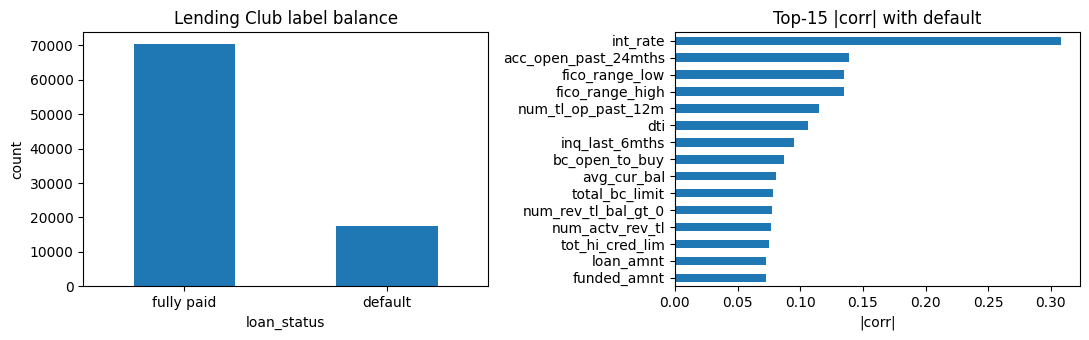

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
y_lc.value_counts().rename({0: 'fully paid', 1: 'default'}).plot.bar(ax=axes[0], rot=0)
axes[0].set(title='Lending Club label balance', ylabel='count')

X_lc_varying = X_lc.loc[:, X_lc.std(numeric_only=True) > 0]
top_lc = X_lc_varying.corrwith(y_lc).abs().dropna().sort_values(ascending=False).head(15)
top_lc.iloc[::-1].plot.barh(ax=axes[1])
axes[1].set(title='Top-15 |corr| with default', xlabel='|corr|')
plt.tight_layout()
plt.show()

## Summary

In [11]:
summary = pd.DataFrame(
    [
        {'dataset': 'communities', 'task': 'regression',     'n_samples': len(y_cc), 'n_features': X_cc.shape[1], 'target_mean': round(float(y_cc.mean()), 3)},
        {'dataset': 'nhanes',      'task': 'classification', 'n_samples': len(y_nh), 'n_features': X_nh.shape[1], 'target_mean': round(float(y_nh.mean()), 3)},
        {'dataset': 'lending_club','task': 'classification', 'n_samples': len(y_lc), 'n_features': X_lc.shape[1], 'target_mean': round(float(y_lc.mean()), 3)},
    ]
)
summary

,dataset,task,n_samples,n_features,target_mean
0,communities,regression,1994,100,0.238
1,nhanes,classification,9236,112,0.078
2,lending_club,classification,87892,57,0.200
